# Researching a Pairs Trading Strategy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels
import statsmodels.api as sm

# Random Number Generator
rng = np.random.default_rng(seed=12345)

## Start by simulating returns of some imaginary asset


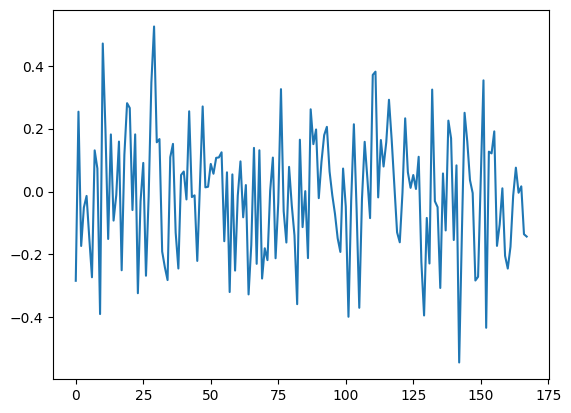

In [2]:
X_return_mean = 0.001;
X_return_stddev = 0.2;
window_size = 168;

X_returns = rng.normal(X_return_mean, X_return_stddev, window_size);

pd.Series(X_returns).plot();

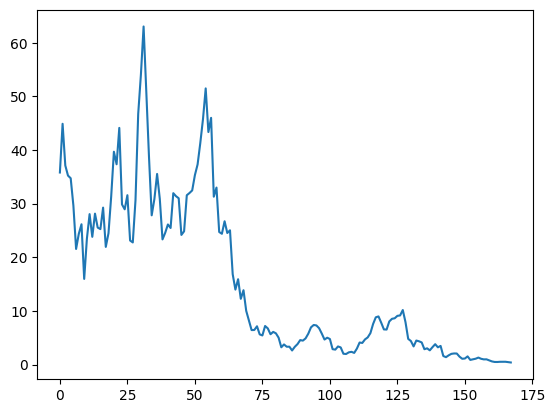

In [3]:
X_initial_price = 50;

X = pd.Series(X_initial_price * (1 + X_returns).cumprod(), name = "X Price");
X.plot();

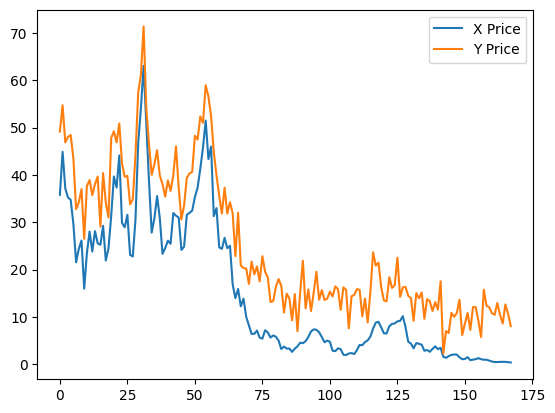

In [4]:
noise = rng.normal(0, 3, window_size);
Y = X + noise + 10;
Y.name = "Y Price";
pd.concat([X, Y], axis = 1).plot();

## Cointegration

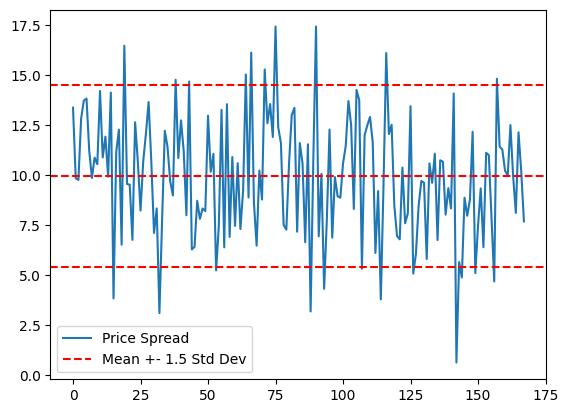

In [5]:
diff = Y - X
diff_mean = diff.mean()
diff_std = diff.std()
n_std_devs = 1.5

diff.plot()
plt.axhline(diff_mean, color="red", linestyle="--")
plt.axhline(diff_mean + n_std_devs * diff_std, color="red", linestyle="--")
plt.axhline(diff_mean - n_std_devs * diff_std, color="red", linestyle="--")
plt.legend(["Price Spread", f"Mean +- {n_std_devs} Std Dev"])

plt.show();


### Testing for cointegration

**WARNING**: ALWAYS PICK THE P-VALUE THRESHOLD BEFORE LOOKING AT THE RESULTS

In [6]:
from statsmodels.tsa.stattools import coint

def test_cointegration(X: pd.Series, Y: pd.Series, p_value_threshold: float = 0.05):
    _, p_value, _ = coint(X, Y)

    if p_value < p_value_threshold:
        print(f"The series {X.name} and {Y.name} are cointegrated")
    else:
        print(f"The series {X.name} and {Y.name} are not cointegrated")

test_cointegration(X, Y)

The series X Price and Y Price are cointegrated


## Looking for Cointegrated Pairs

In [14]:
candles_file_path = "../data/ohlcv1d.csv"
tickers = ["BTC", "ETH", "XRP", "SOL", "BCH", "LTC"]
symbols = [f"{ticker}/USDC:USDC" for ticker in tickers]

# Read the data
df = pd.read_csv(candles_file_path, parse_dates=["timestamp"])

# Pivot to get each symbol's close as a column
prices_df = df.pivot(
    index="timestamp",
    columns="symbol",
    values="close"
)[symbols]

# Rename columns to just show the ticker
prices_df.columns = tickers

prices_df.head()

,BTC,ETH,XRP,SOL,BCH,LTC
timestamp,,,,,,
2023-06-01 00:00:00+00:00,26802.0,1860.3,0.5061,20.486,113.27,94.151
2023-06-02 00:00:00+00:00,27223.0,1905.8,0.5241,21.220,114.80,95.508
2023-06-03 00:00:00+00:00,27057.0,1891.7,0.5186,21.180,114.91,96.001
2023-06-04 00:00:00+00:00,27122.0,1889.6,0.5354,21.815,115.60,94.208
2023-06-05 00:00:00+00:00,25707.0,1810.8,0.5085,19.995,108.56,87.615


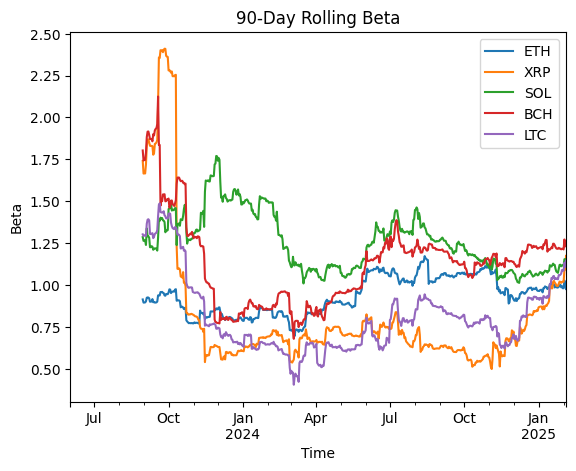

In [15]:
from statsmodels.regression.rolling import RollingOLS

index_ticker = "BTC"
index_prices = prices_df[index_ticker]
index_returns = index_prices.pct_change().dropna()

betas = pd.DataFrame(index=prices_df.index)
days = 90

for asset_ticker in tickers:
    if asset_ticker == index_ticker:
        continue

    asset_prices = prices_df[asset_ticker]
    asset_returns = asset_prices.pct_change().dropna()

    # test_cointegration(BTC, XRP)

    rols = RollingOLS(asset_returns, index_returns, window=days)
    betas[asset_ticker] = rols.fit().params


betas.plot()
plt.title(f"{days}-Day Rolling Beta")
plt.xlabel("Time")
plt.ylabel("Beta")
plt.show();
